# Chapter 2 — Data and Sampling Distributions

## Pendahuluan

Chapter ini membahas bagaimana sampel digunakan untuk mempelajari suatu populasi. Pengambilan sampel tetap penting meskipun tersedia banyak data, karena kualitas dan keterwakilan data memengaruhi hasil analisis.

Sampel yang berbeda dapat menghasilkan nilai statistik yang berbeda, misalnya rata-rata yang berbeda. Distribusi sampling membantu menjelaskan variasi tersebut dan menjadi dasar untuk mengukur ketidakpastian dalam estimasi.

Notebook ini mereproduksi contoh kode Python dari Chapter 2 buku *Practical Statistics for Data Scientists*, edisi kedua. Setiap materi dilengkapi penjelasan teori, kode, hasil eksekusi, dan interpretasi.

## Tujuan Pembelajaran

1. Memahami populasi, sampel, pengambilan sampel acak, dan bias.
2. Membedakan distribusi data dengan distribusi sampling.
3. Memahami central limit theorem dan standard error.
4. Menggunakan bootstrap untuk mempelajari variasi suatu statistik.
5. Memahami confidence interval sebagai ukuran ketidakpastian estimasi.
6. Mengenali distribusi probabilitas yang dibahas dalam chapter ini, termasuk normal, t, binomial, chi-square, F, Poisson, eksponensial, dan Weibull.

## Persiapan Library

Notebook ini menggunakan pandas untuk mengolah data berbentuk tabel, NumPy untuk perhitungan numerik, dan SciPy untuk fungsi statistik serta distribusi probabilitas.

Fungsi `resample` dari scikit-learn digunakan untuk pengambilan sampel ulang. Matplotlib dan Seaborn digunakan untuk membuat grafik.

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

print("Library Chapter 2 siap digunakan.")

Library Chapter 2 siap digunakan.


## 1. Populasi, Sampel, dan Sampling Acak

**Populasi (population)** adalah keseluruhan objek atau pengamatan yang ingin dipelajari. Contohnya, seluruh 1.000 mahasiswa di suatu kampus.

**Sampel (sample)** adalah sebagian anggota populasi yang digunakan dalam analisis. Contohnya, 100 mahasiswa yang dipilih dari 1.000 mahasiswa tersebut.

**Sampling acak (random sampling)** menggunakan proses acak untuk memilih anggota sampel. Dalam simple random sampling, setiap anggota populasi memiliki kesempatan yang sama untuk terpilih.

Sampel acak dapat berbeda dari populasi karena variasi kebetulan. Oleh karena itu, hasil dari satu sampel tidak selalu persis mencerminkan karakteristik populasi.

### Ilustrasi Populasi dan Sampel

Contoh berikut mereproduksi ilustrasi Figure 2.1 dari buku. Distribusi normal standar digunakan sebagai model populasi, kemudian 1.000 pengamatan disimulasikan dari model tersebut. Judul, label, ukuran, dan rentang grafik disesuaikan agar mudah dibaca.

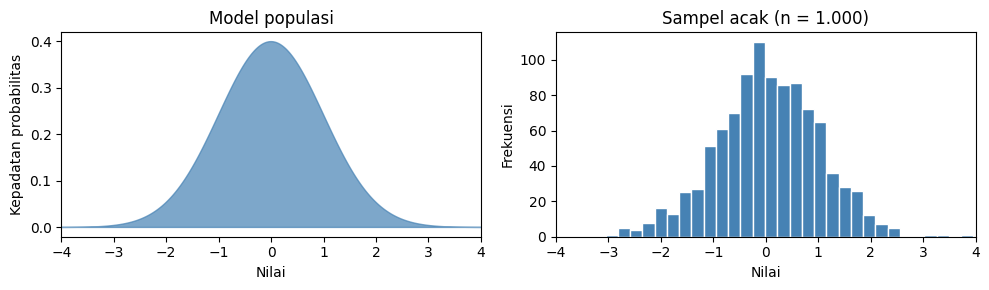

In [4]:
np.random.seed(seed=1)

# Titik x untuk menggambar kurva, bukan data populasi.
x = np.linspace(-4, 4, 400)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(10, 3))

axes[0].fill(x, stats.norm.pdf(x), color="steelblue", alpha=0.7)
axes[0].set_title("Model populasi")
axes[0].set_ylabel("Kepadatan probabilitas")

axes[1].hist(xsample, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Sampel acak (n = 1.000)")
axes[1].set_ylabel("Frekuensi")

for ax in axes:
    ax.set_xlabel("Nilai")
    ax.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Grafik kiri menunjukkan model populasi berupa distribusi normal standar, dengan rata-rata 0 dan standar deviasi 1. Kurva menggambarkan kepadatan probabilitas.

Grafik kanan menunjukkan distribusi empiris dari 1.000 pengamatan sampel. Tinggi batang menyatakan banyaknya pengamatan dalam setiap interval.

Histogram memiliki bentuk umum yang menyerupai kurva populasi, tetapi batangnya tidak membentuk kurva yang sepenuhnya mulus karena jumlah pengamatan terbatas dan terdapat variasi acak.

Perintah `np.random.seed(seed=1)` mengatur pengacakan agar contoh ini menghasilkan sampel yang sama ketika sel dijalankan ulang dalam lingkungan yang sama.

## 2. Sampling dengan dan Tanpa Pengembalian

**Tanpa pengembalian (without replacement):** anggota yang sudah terpilih tidak tersedia untuk pengambilan berikutnya dalam sampel yang sama. Setiap anggota hanya dapat terpilih sekali.

**Dengan pengembalian (with replacement):** anggota yang terpilih dikembalikan sebelum pengambilan berikutnya. Anggota tersebut dapat terpilih lebih dari sekali.

Contoh berikut merupakan latihan tambahan untuk memperjelas teori dalam buku. Kita menggunakan populasi sederhana berisi lima ID unik, kemudian mengambil empat anggota dengan kedua metode.

In [5]:
population_demo = pd.Series(["A", "B", "C", "D", "E"], name="ID")

sample_without_replacement = population_demo.sample(
    n=4, replace=False, random_state=42
)

sample_with_replacement = population_demo.sample(
    n=4, replace=True, random_state=42
)

print("Populasi:", population_demo.tolist())
print("Tanpa pengembalian:", sample_without_replacement.tolist())
print("Dengan pengembalian:", sample_with_replacement.tolist())

Populasi: ['A', 'B', 'C', 'D', 'E']
Tanpa pengembalian: ['B', 'E', 'C', 'A']
Dengan pengembalian: ['D', 'E', 'C', 'E']


### Interpretasi Hasil

Sampel tanpa pengembalian berisi empat ID berbeda. Tidak ada anggota yang terpilih berulang dalam sampel tersebut.

Pada sampel dengan pengembalian, ID E terpilih dua kali. Hal ini diperbolehkan karena setiap anggota tetap tersedia untuk pengambilan berikutnya.

Parameter `n=4` menentukan jumlah pengambilan. Parameter `replace=False` berarti tanpa pengembalian, sedangkan `replace=True` berarti dengan pengembalian.

Parameter `random_state=42` mengatur pengacakan agar hasil contoh dapat direproduksi ketika dijalankan ulang dalam lingkungan yang sama.

## 3. Bias Sampel (Sample Bias)

**Bias** adalah kesalahan sistematis yang berasal dari proses pengukuran atau pemilihan data. **Bias sampel** terjadi ketika cara memilih sampel membuat kelompok tertentu terlalu banyak atau terlalu sedikit terwakili dibandingkan populasi yang ingin dipelajari.

### Kesalahan Acak dan Bias

Kesalahan acak muncul karena variasi kebetulan antar-sampel. Dengan metode sampling yang sesuai, memperbesar sampel biasanya mengurangi variasi ini.

Bias berasal dari masalah sistematis dalam proses pengumpulan data. Memperbesar sampel dengan metode yang tetap bias tidak otomatis memperbaiki hasilnya.

### Self-Selection Bias

Self-selection bias dapat terjadi ketika orang memilih sendiri untuk berpartisipasi.

Contohnya, ulasan restoran ditulis oleh pelanggan yang terdorong memberikan ulasan. Karakteristik atau pengalaman mereka mungkin berbeda dari pelanggan yang tidak menulis ulasan. Karena itu, ulasan tersebut belum tentu mewakili seluruh pelanggan restoran.

### Mengurangi Bias Sampel

Upaya untuk mengurangi bias meliputi:

1. Mendefinisikan populasi sasaran dengan jelas.
2. Memastikan daftar atau sumber pengambilan sampel mencakup populasi sasaran.
3. Menggunakan pemilihan acak dari sumber tersebut.
4. Memperhatikan kelompok dan waktu pengumpulan data yang mungkin kurang terwakili.

Sampling acak tetap bergantung pada cakupan sumber datanya. Jika suatu kelompok tidak masuk dalam daftar pengambilan sampel, kelompok tersebut tidak memiliki kesempatan untuk terpilih.

### Hubungan dengan Machine Learning

Model yang dilatih menggunakan data yang kurang mewakili populasi sasaran dapat menghasilkan prediksi yang kurang sesuai ketika digunakan pada populasi tersebut. Oleh karena itu, kualitas dan keterwakilan data perlu diperiksa sebelum pelatihan model.

## 4. Sampling Berstrata (Stratified Sampling)

**Sampling berstrata** membagi populasi menjadi kelompok yang disebut **strata**, kemudian mengambil sampel secara acak dari setiap kelompok.

Satu kelompok disebut **stratum**. Anggota dalam stratum memiliki karakteristik tertentu yang sama, misalnya program studi atau wilayah tempat tinggal. Setiap anggota populasi dimasukkan ke satu stratum.

### Contoh Sampling Berstrata Proporsional

Misalkan populasi terdiri dari 1.000 mahasiswa dan kita ingin mengambil sampel sebanyak 100 mahasiswa.

| Program Studi | Jumlah dalam Populasi | Proporsi Populasi | Jumlah Sampel |
| --- | ---: | ---: | ---: |
| A | 600 | 60% | 60 |
| B | 400 | 40% | 40 |
| **Total** | **1.000** | **100%** | **100** |

Kita memilih 60 mahasiswa secara acak dari Program Studi A dan 40 mahasiswa secara acak dari Program Studi B.

Alokasi ini mempertahankan proporsi kedua program studi dalam sampel. Angka pada tabel merupakan contoh tambahan untuk menjelaskan konsep.

### Tujuan dan Pilihan Alokasi

Sampling berstrata membantu memastikan kelompok yang relevan masuk dalam sampel. Dengan pembagian strata yang sesuai, metode ini juga dapat meningkatkan ketelitian estimasi.

Jumlah sampel setiap stratum dapat dibuat proporsional terhadap ukuran kelompoknya. Kelompok kecil juga dapat diambil dalam proporsi lebih besar agar tersedia cukup data untuk analisis kelompok tersebut.

Jika alokasi tidak proporsional, estimasi untuk seluruh populasi perlu memperhitungkan bobot sesuai desain sampling.

## 5. Ukuran dan Kualitas Sampel (Size Versus Quality)

**Ukuran sampel** adalah jumlah pengamatan yang digunakan dalam analisis. **Kualitas sampel** mencakup kelengkapan data, konsistensi format, kebersihan, ketepatan pengukuran, dan keterwakilan populasi sasaran.

### Mengapa Kualitas Penting?

Kesalahan pengukuran, data yang tidak lengkap, atau proses pemilihan yang bias dapat memengaruhi hasil analisis. Memperbesar jumlah data tidak otomatis mengatasi masalah tersebut.

Sampel yang dipilih dengan baik juga memudahkan pemeriksaan data. Peneliti dapat menelusuri nilai yang hilang, memeriksa outlier, dan membuat visualisasi dengan waktu serta biaya yang lebih terjangkau.

### Kapan Ukuran Sampel Penting?

Dengan metode sampling yang tepat dan asumsi yang sesuai, sampel lebih besar biasanya mengurangi variasi acak dalam estimasi.

Data dalam jumlah besar juga penting ketika pola yang ingin dipelajari jarang muncul. Contohnya, kombinasi kata pencarian yang sangat jarang membutuhkan banyak catatan pencarian agar tersedia cukup contoh yang relevan.

Hal ini terutama berguna pada data sparse, misalnya matriks yang sebagian besar nilainya nol.

### Hubungan dengan Machine Learning

Pemilihan jumlah data perlu mempertimbangkan tujuan model, keragaman populasi, kualitas pengamatan, dan ketersediaan contoh untuk pola yang jarang terjadi. Pemeriksaan kualitas tetap diperlukan saat jumlah data bertambah.

## 6. Rata-rata Sampel dan Rata-rata Populasi

Rata-rata populasi dan rata-rata sampel dibedakan karena keduanya dihitung dari kumpulan pengamatan yang berbeda.

| Ukuran | Simbol | Dihitung dari | Jenis |
| --- | --- | --- | --- |
| Rata-rata populasi | $\mu$ (mu) | Seluruh anggota populasi | Parameter |
| Rata-rata sampel | $\bar{x}$ (x-bar) | Anggota sampel | Statistik |

**Parameter** menggambarkan karakteristik populasi, sedangkan **statistik** dihitung dari data sampel.

### Rumus

Untuk populasi berhingga dengan jumlah anggota $N$:

$$
\mu = \frac{1}{N}\sum_{i=1}^{N} X_i
$$

Untuk sampel dengan jumlah pengamatan $n$:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

Pada rumus pertama, $X_i$ adalah nilai anggota populasi. Pada rumus kedua, $x_i$ adalah nilai pengamatan sampel.

### Contoh Tambahan

Misalkan populasi berisi nilai 10, 20, 30, dan 40. Rata-rata populasinya adalah:

$$
\mu = \frac{10+20+30+40}{4} = 25
$$

Jika sampel yang diperoleh berisi 10 dan 20, rata-rata sampelnya adalah:

$$
\bar{x} = \frac{10+20}{2} = 15
$$

Rata-rata sampel tersebut berbeda dari rata-rata populasi. Sampel lain dapat menghasilkan rata-rata yang berbeda lagi.

### Peran dalam Estimasi

Ketika seluruh data populasi tidak tersedia, rata-rata sampel digunakan untuk memperkirakan rata-rata populasi.

Nilai $\mu$ tetap untuk populasi yang sama, sedangkan $\bar{x}$ dapat berubah antar-sampel. Variasi statistik antar-sampel menjadi dasar pembahasan distribusi sampling.

## 7. Selection Bias

**Selection bias** muncul ketika cara memilih pengamatan atau hasil analisis menghasilkan kesimpulan yang menyesatkan. Pemilihan tersebut dapat dilakukan secara sadar maupun tidak sadar.

Contohnya adalah memilih data yang mendukung suatu kesimpulan, memilih periode waktu dengan hasil paling menarik, atau menghentikan eksperimen saat hasil terlihat menguntungkan.

### Data Snooping

**Data snooping** adalah pencarian pola secara luas dan berulang dalam data sampai ditemukan sesuatu yang menarik.

Pola yang ditemukan perlu diperiksa menggunakan data atau pengujian tambahan karena sebagian pola dapat muncul secara kebetulan.

### Vast Search Effect

**Vast search effect** adalah risiko menemukan hasil yang tampak kuat karena mencoba sangat banyak model, pertanyaan, atau variabel prediktor.

Semakin banyak percobaan dilakukan, semakin besar kesempatan menemukan hasil ekstrem akibat variasi acak. Proses pemilihan hasil terbaik perlu diperhitungkan ketika menilai hasil tersebut.

### Contoh Koin dalam Buku

Untuk koin adil dengan lemparan independen, peluang satu orang mendapatkan heads pada 10 lemparan berturut-turut adalah:

$$
P = (0.5)^{10} = \frac{1}{1024}
$$

Namun, jika 20.000 orang masing-masing melakukan 10 lemparan, peluang setidaknya satu orang memperoleh hasil tersebut menjadi sangat tinggi.

Memilih orang yang berhasil setelah seluruh percobaan selesai melibatkan banyak kesempatan menghasilkan kejadian langka. Penilaiannya harus memperhitungkan proses seleksi tersebut.

### Hubungan dengan Machine Learning

Mencoba banyak model dan memilih skor terbaik pada data yang sama dapat menghasilkan penilaian performa yang terlalu optimistis.

Data pengembangan digunakan untuk memilih dan menyempurnakan model. Data uji akhir yang terpisah disimpan untuk evaluasi setelah keputusan pengembangan selesai.

Buku juga membahas **target shuffling**, yaitu pengacakan label target untuk menilai apakah hubungan prediktif yang ditemukan lebih kuat daripada hubungan yang dapat muncul secara kebetulan.

## 8. Regression to the Mean

**Regression to the mean** adalah kecenderungan pengamatan yang sangat ekstrem diikuti pengamatan yang lebih dekat ke pusat distribusi.

Fenomena ini dapat terjadi ketika nilai ekstrem sebagian dipengaruhi variasi acak, bukan hanya karakteristik yang menetap.

### Contoh dalam Buku

Buku menggunakan contoh atlet dengan performa terbaik pada musim pertamanya. Performa tersebut dapat mencerminkan kombinasi keterampilan dan keberuntungan.

Pada musim berikutnya, keterampilannya mungkin tetap sama, tetapi keberuntungan yang sangat menguntungkan belum tentu terulang. Akibatnya, performanya dapat menjadi lebih dekat ke tingkat yang biasa dicapai.

Kecenderungan serupa dapat terjadi pada hasil yang sangat rendah. Fenomena ini merupakan kecenderungan statistik, bukan kepastian untuk setiap individu.

### Hubungan dengan Selection Bias

Ketika kita memilih pengamatan karena hasilnya sangat ekstrem, kita juga dapat memilih pengamatan dengan komponen kebetulan yang besar.

Perubahan pada pengukuran berikutnya perlu mempertimbangkan pengaruh variasi acak. Misalnya, peningkatan setelah memilih kelompok dengan skor awal sangat rendah belum cukup untuk menyimpulkan bahwa suatu program menyebabkan peningkatan tersebut.

### Perbedaan Istilah

| Istilah | Makna |
| --- | --- |
| Regression to the mean | Fenomena nilai ekstrem yang cenderung diikuti nilai lebih dekat ke pusat distribusi |
| Regresi linear | Metode pemodelan untuk memperkirakan hubungan linear antara variabel prediktor dan variabel respons |

Kedua istilah menggunakan kata “regresi”, tetapi menjelaskan konsep yang berbeda.

## 9. Persiapan Dataset Pendapatan

Dataset `loans_income.csv` dari repository pendamping buku berisi pendapatan tahunan pemohon pinjaman LendingClub.

Data ini akan digunakan untuk mempelajari distribusi sampling, bootstrap, dan confidence intervals.

Dataset dibaca menggunakan pandas. Karena hanya memiliki satu kolom, data diubah menjadi Series agar mudah digunakan untuk pengambilan sampel dan perhitungan statistik.

In [6]:
LOANS_INCOME_CSV = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/loans_income.csv"
)

loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze("columns")

print("Jumlah pengamatan:", len(loans_income))
print("Lima nilai pendapatan pertama:")
print(loans_income.head())

Jumlah pengamatan: 50000
Lima nilai pendapatan pertama:
0     67000
1     52000
2    100000
3     78762
4     37041
Name: x, dtype: int64


### Interpretasi Data

Dataset berisi 50.000 pengamatan pendapatan tahunan. Setiap nilai merupakan pendapatan seorang pemohon pinjaman dalam data latihan.

Kolom pada file CSV bernama `x`. Setelah dibaca dan diubah menjadi Series, data disimpan dalam variabel `loans_income`.

Fungsi `len()` menghitung jumlah pengamatan, sedangkan `.head()` menampilkan lima pengamatan pertama.

Selanjutnya, data ini digunakan untuk membandingkan distribusi nilai pendapatan dengan distribusi rata-rata sampel.

## 10. Distribusi Sampling (Sampling Distribution)

Distribusi data menunjukkan penyebaran nilai individual dalam suatu dataset. Distribusi sampling menunjukkan penyebaran suatu statistik, seperti rata-rata, dari banyak sampel yang diambil berulang kali.

Dalam contoh ini, dataset pendapatan digunakan sebagai sumber pengambilan sampel untuk membuat tiga histogram:

| Grafik | Nilai yang ditampilkan |
|---|---|
| Data | 1.000 nilai pendapatan individual |
| Mean of 5 | 1.000 rata-rata, masing-masing dihitung dari sampel berukuran 5 |
| Mean of 20 | 1.000 rata-rata, masing-masing dihitung dari sampel berukuran 20 |

Angka 1.000 pada dua kelompok terakhir merupakan jumlah pengulangan. Ukuran setiap sampelnya adalah 5 atau 20.

Tujuannya adalah mengamati bagaimana ukuran sampel memengaruhi penyebaran rata-rata sampel.

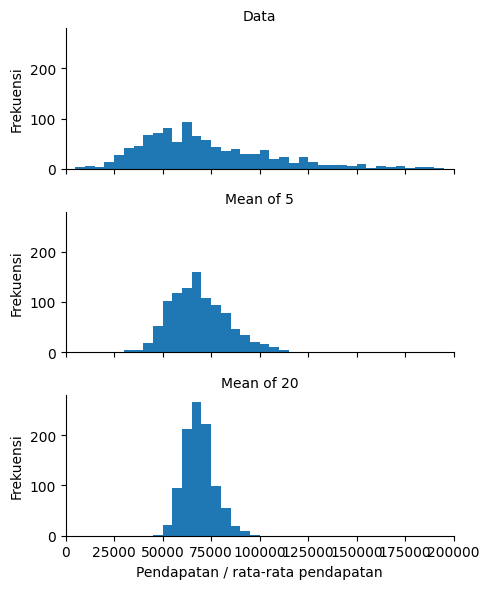

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(seed=1)

# 1. Ambil 1.000 nilai pendapatan individual.
sample_data = pd.DataFrame({
    "income": loans_income.sample(n=1000, replace=False),
    "type": "Data",
})

# 2. Sampel berukuran 5: hitung rata-rata, ulangi 1.000 kali.
sample_mean_05 = pd.DataFrame({
    "income": [loans_income.sample(n=5, replace=False).mean()
               for _ in range(1000)],
    "type": "Mean of 5",
})

# 3. Sampel berukuran 20: hitung rata-rata, ulangi 1.000 kali.
sample_mean_20 = pd.DataFrame({
    "income": [loans_income.sample(n=20, replace=False).mean()
               for _ in range(1000)],
    "type": "Mean of 20",
})

results = pd.concat(
    [sample_data, sample_mean_05, sample_mean_20],
    ignore_index=True,
)

g = sns.FacetGrid(
    results, col="type", col_wrap=1, height=2, aspect=2.5
)
g.map(plt.hist, "income", range=(0, 200000), bins=40)
g.set_axis_labels("Pendapatan / rata-rata pendapatan", "Frekuensi")
g.set_titles("{col_name}")
g.set(xlim=(0, 200000))

plt.tight_layout()
plt.show()

### Interpretasi Distribusi Sampling

Distribusi pendapatan individual cenderung memiliki penyebaran lebar dan ekor ke kanan karena sebagian pemohon memiliki pendapatan yang jauh lebih tinggi.

Distribusi rata-rata sampel cenderung lebih rapat. Rata-rata dari sampel berukuran 20 umumnya memiliki variasi yang lebih kecil dibandingkan rata-rata dari sampel berukuran 5.

Hal ini menunjukkan bahwa rata-rata sampel menjadi lebih stabil ketika ukuran sampel meningkat. Data pendapatan individualnya sendiri tidak berubah menjadi berdistribusi normal.

Setiap pengulangan mengambil sampel baru dari seluruh dataset. Karena itu, seorang pemohon dapat terpilih kembali pada pengulangan lain.

Grafik menampilkan rentang 0–200.000 sesuai contoh buku. Nilai di luar rentang tersebut tidak ditampilkan pada histogram, tetapi tetap tersedia dalam dataset.

## 11. Central Limit Theorem (Teorema Limit Pusat)

Central Limit Theorem menjelaskan bahwa distribusi rata-rata sampel akan mendekati distribusi normal ketika ukuran setiap sampel cukup besar, meskipun distribusi data asal tidak normal.

Dalam bentuk dasarnya, teorema ini berlaku untuk pengamatan yang independen, berasal dari distribusi yang sama, serta memiliki rata-rata dan varians berhingga.

### Hubungan dengan Grafik Sebelumnya

Pendapatan individual memiliki distribusi yang cenderung miring ke kanan. Namun, ketika banyak sampel diambil dan rata-rata setiap sampel dihitung, distribusi rata-rata tersebut cenderung lebih menyerupai bentuk lonceng.

Pada contoh sebelumnya:

- **Data** menunjukkan penyebaran pendapatan individual.
- **Mean of 5** menunjukkan penyebaran rata-rata sampel berukuran 5.
- **Mean of 20** menunjukkan penyebaran rata-rata sampel berukuran 20, yang cenderung lebih mendekati bentuk lonceng.

Rata-rata sampel juga cenderung semakin terkonsentrasi di sekitar rata-rata populasi ketika ukuran sampel meningkat.

### Ukuran Sampel dan Jumlah Pengulangan

Ukuran sampel adalah banyaknya pengamatan yang digunakan untuk menghitung satu rata-rata, yaitu 5 atau 20 pada latihan ini.

Jumlah pengulangan adalah banyaknya rata-rata yang dihitung, yaitu 1.000. Menambah pengulangan membantu memperlihatkan bentuk distribusi sampling dengan lebih jelas; menambah ukuran sampel memengaruhi distribusi rata-rata itu sendiri.

### Hal yang Perlu Dipahami

CLT membahas distribusi rata-rata sampel. Data individualnya tidak otomatis berubah menjadi berdistribusi normal.

Tidak ada ukuran sampel minimum yang selalu cukup untuk semua distribusi. Data yang sangat miring dapat membutuhkan sampel lebih besar agar pendekatan normal cukup baik. Karena itu, sampel berukuran 20 belum tentu menghasilkan distribusi rata-rata yang sudah mendekati normal.

CLT menjadi dasar bagi sejumlah pendekatan normal dalam perhitungan confidence intervals dan pengujian hipotesis.

## 12. Standard Error

Standard error adalah simpangan baku distribusi sampling suatu statistik. Untuk rata-rata, SE menunjukkan seberapa besar rata-rata dapat berubah antarsampel.

### Perbedaan Standard Deviation dan Standard Error

| Ukuran | Apa yang diukur? |
|---|---|
| Standard deviation (SD) | Penyebaran nilai individual |
| Standard error rata-rata (SE) | Penyebaran rata-rata dari banyak sampel |

Untuk pengamatan independen dari distribusi yang sama dengan varians berhingga, SE rata-rata dapat diestimasi menggunakan:

$$
\widehat{SE}(\bar{X}) = \frac{s}{\sqrt{n}}
$$

Keterangan:

- $s$: simpangan baku nilai individual dalam sampel.
- $n$: jumlah pengamatan dalam satu sampel.

Rumus ini tidak mengharuskan data individual berdistribusi normal.

### Pengaruh Ukuran Sampel

Semakin besar ukuran sampel, semakin kecil SE rata-rata.

Untuk mengurangi SE menjadi setengah, ukuran sampel perlu diperbesar empat kali. Pada latihan sebelumnya, ukuran sampel meningkat dari 5 menjadi 20, sehingga SE yang diharapkan kira-kira menjadi setengah.

### Mengestimasi SE melalui Simulasi

Jika banyak rata-rata sampel sudah tersedia, SE dapat diestimasi langsung dengan menghitung simpangan baku dari kumpulan rata-rata tersebut.

Cara ini akan digunakan pada latihan berikut.

In [8]:
se_n5 = sample_mean_05["income"].std(ddof=1)
se_n20 = sample_mean_20["income"].std(ddof=1)

print(f"Estimasi SE rata-rata (n = 5): {se_n5:,.2f}")
print(f"Estimasi SE rata-rata (n = 20): {se_n20:,.2f}")
print(f"Rasio SE n=20 terhadap n=5: {se_n20 / se_n5:.2f}")

Estimasi SE rata-rata (n = 5): 14,597.49
Estimasi SE rata-rata (n = 20): 7,625.45
Rasio SE n=20 terhadap n=5: 0.52


### Interpretasi Standard Error

Pada latihan ini, estimasi SE diperoleh dari simpangan baku 1.000 rata-rata sampel pada setiap kelompok.

SE untuk sampel berukuran 20 cenderung lebih kecil dibandingkan SE untuk sampel berukuran 5. Hal ini menunjukkan bahwa rata-rata dari sampel yang lebih besar memiliki variasi antarsampel yang lebih kecil.

Angka 1.000 merupakan jumlah pengulangan simulasi, sedangkan ukuran setiap sampelnya adalah 5 atau 20. Simpangan baku kumpulan rata-rata tersebut sudah merupakan estimasi SE; tidak perlu dibagi lagi dengan akar 1.000.

SE yang kecil menunjukkan presisi yang lebih tinggi, tetapi tidak menjamin bahwa estimasi bebas dari bias.

## 13. Bootstrap

Bootstrap adalah metode untuk memperkirakan distribusi sampling suatu statistik dengan mengambil sampel ulang dari data yang tersedia, menggunakan pengambilan dengan pengembalian.

Dengan pengembalian berarti satu pengamatan dapat terpilih lebih dari sekali dalam satu sampel bootstrap.

Resampling merupakan istilah umum yang mencakup bootstrap dan metode lain, seperti permutasi. Bootstrap secara khusus menggunakan pengambilan dengan pengembalian.

### Langkah Bootstrap

1. Ambil sampel ulang dengan pengembalian dari dataset.
2. Gunakan ukuran sampel ulang yang sama dengan jumlah pengamatan pada dataset asal.
3. Hitung statistik yang ingin dipelajari, misalnya median.
4. Ulangi proses tersebut dan kumpulkan hasil statistiknya.

Pada contoh ini, setiap sampel bootstrap berisi 50.000 pengamatan. Proses diulang 1.000 kali sehingga menghasilkan 1.000 median.

Simpangan baku kumpulan median tersebut digunakan untuk mengestimasi standard error median.

Bootstrap tidak mengharuskan data berdistribusi normal. Namun, bootstrap sederhana ini mengasumsikan pengamatan dapat diperlakukan independen, dan kualitas hasilnya tetap bergantung pada data asal.

In [9]:
import numpy as np
import pandas as pd
from sklearn.utils import resample

np.random.seed(seed=1)

bootstrap_medians = []

for _ in range(1000):
    bootstrap_sample = resample(
        loans_income,
        replace=True,
        n_samples=len(loans_income),
    )
    bootstrap_medians.append(bootstrap_sample.median())

bootstrap_medians = pd.Series(bootstrap_medians)

original_median = loans_income.median()
bootstrap_bias = bootstrap_medians.mean() - original_median
bootstrap_se = bootstrap_medians.std(ddof=1)

print("Bootstrap Statistics:")
print(f"original: {original_median:,.2f}")
print(f"bias: {bootstrap_bias:,.2f}")
print(f"std. error: {bootstrap_se:,.2f}")

Bootstrap Statistics:
original: 62,000.00
bias: -69.88
std. error: 211.65


### Interpretasi Hasil Bootstrap

| Output | Makna |
|---|---|
| original | Median pendapatan pada dataset asal |
| bias | Rata-rata median bootstrap dikurangi median dataset asal |
| std. error | Simpangan baku 1.000 median bootstrap |

Jika bias bernilai negatif, rata-rata median bootstrap berada di bawah median asal. Jika positif, rata-ratanya berada di atas median asal.

Nilai bias tersebut merupakan estimasi bias bootstrap untuk statistik median. Nilai ini tidak menunjukkan seluruh kemungkinan bias dalam pengumpulan atau pemilihan data.

Standard error menggambarkan variasi median antarsampel bootstrap, bukan penyebaran pendapatan individual.

Bootstrap tidak menciptakan informasi baru atau memperbaiki data yang tidak mewakili populasi. Menambah jumlah pengulangan membantu menstabilkan hasil simulasi, tetapi tidak menambah jumlah pengamatan asli.

Dalam machine learning, beberapa model dapat dilatih menggunakan sampel bootstrap. Penggabungan prediksi model-model tersebut disebut bagging atau bootstrap aggregating.

## 14. Confidence Intervals

Confidence interval atau interval kepercayaan adalah rentang estimasi untuk suatu parameter populasi, misalnya rata-rata.

Interval memiliki dua batas: batas bawah dan batas atas. Rentang ini membantu menunjukkan ketidakpastian estimasi dari sampel.

### Bootstrap Confidence Interval 90%

Pada latihan ini, dataset lengkap diperlakukan sebagai populasi acuan. Langkah perhitungannya adalah:

1. Ambil sampel awal berukuran 20 tanpa pengembalian dari dataset.
2. Ambil sampel bootstrap berukuran 20 dengan pengembalian dari sampel awal tersebut.
3. Hitung rata-rata sampel bootstrap.
4. Ulangi proses bootstrap sebanyak 500 kali.
5. Gunakan persentil ke-5 sebagai batas bawah dan persentil ke-95 sebagai batas atas.

Rentang antara kedua persentil tersebut mencakup sekitar 90% bagian tengah distribusi rata-rata bootstrap. Cara ini disebut metode bootstrap percentile.

Rata-rata dataset acuan: 68,760.52
Rata-rata sampel (n = 20): 55,734.10
CI 90% rata-rata: [43,212.45, 70,233.44]


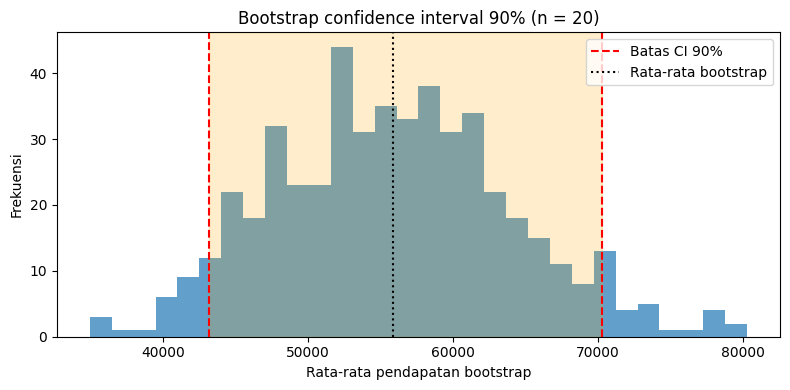

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

np.random.seed(seed=3)

# Sampel awal: 20 pengamatan tanpa pengembalian.
sample20_ci = resample(loans_income, n_samples=20, replace=False)

# Bootstrap dari sampel awal.
bootstrap_means_ci = []

for _ in range(500):
    bootstrap_sample = resample(
        sample20_ci, n_samples=len(sample20_ci), replace=True
    )
    bootstrap_means_ci.append(bootstrap_sample.mean())

bootstrap_means_ci = pd.Series(bootstrap_means_ci)
ci90_lower, ci90_upper = bootstrap_means_ci.quantile([0.05, 0.95])

print(f"Rata-rata dataset acuan: {loans_income.mean():,.2f}")
print(f"Rata-rata sampel (n = 20): {sample20_ci.mean():,.2f}")
print(f"CI 90% rata-rata: [{ci90_lower:,.2f}, {ci90_upper:,.2f}]")

ax = bootstrap_means_ci.plot.hist(
    bins=30, figsize=(8, 4), alpha=0.7
)
ax.axvspan(ci90_lower, ci90_upper, color="orange", alpha=0.2)
ax.axvline(
    ci90_lower, color="red", linestyle="--", label="Batas CI 90%"
)
ax.axvline(ci90_upper, color="red", linestyle="--")
ax.axvline(
    bootstrap_means_ci.mean(),
    color="black",
    linestyle=":",
    label="Rata-rata bootstrap",
)

ax.set_xlabel("Rata-rata pendapatan bootstrap")
ax.set_ylabel("Frekuensi")
ax.set_title("Bootstrap confidence interval 90% (n = 20)")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretasi Confidence Interval

Histogram menunjukkan distribusi 500 rata-rata bootstrap yang dihitung dari sampel awal berukuran 20.

Dua garis merah menandai batas bawah dan batas atas CI 90%. Area berwarna oranye menunjukkan rentang di antara kedua batas tersebut. Garis hitam bertitik menunjukkan rata-rata dari hasil bootstrap.

Interval ini digunakan untuk memperkirakan rata-rata populasi acuan. Rata-rata dataset lengkap ditampilkan agar hasil estimasi dapat dibandingkan dengan nilai acuan yang diketahui dalam latihan.

Tingkat kepercayaan mengacu pada cakupan prosedur dalam pengambilan sampel berulang. Untuk tingkat 90%, targetnya adalah sekitar 90% interval yang dibentuk memuat rata-rata populasi.

Cakupan bootstrap percentile merupakan pendekatan. Ketepatannya bergantung pada ukuran sampel, bentuk distribusi, dan kesesuaian asumsi pengambilan sampel.

### 14.1. Perbandingan Confidence Interval 90% dan 95%

Tingkat kepercayaan memengaruhi lebar interval. Untuk data dan metode yang sama, tingkat kepercayaan yang lebih tinggi menghasilkan interval yang lebih lebar.

Pada metode bootstrap percentile, batas interval ditentukan sebagai berikut:

| Tingkat kepercayaan | Batas bawah | Batas atas |
|---|---|---|
| 90% | Persentil ke-5 | Persentil ke-95 |
| 95% | Persentil ke-2,5 | Persentil ke-97,5 |

CI 95% mencakup bagian distribusi bootstrap yang lebih luas dibandingkan CI 90%.

Perbandingan ini menggunakan sampel awal berukuran 20 dan kumpulan 500 rata-rata bootstrap yang sama. Dengan demikian, kita dapat mengamati pengaruh perubahan tingkat kepercayaan terhadap lebar interval.

Lebar interval dihitung dengan mengurangi batas atas dengan batas bawah.

CI 90%: [43,212.45, 70,233.44]
Lebar CI 90%: 27,020.99
CI 95%: [41,262.22, 72,893.77]
Lebar CI 95%: 31,631.55


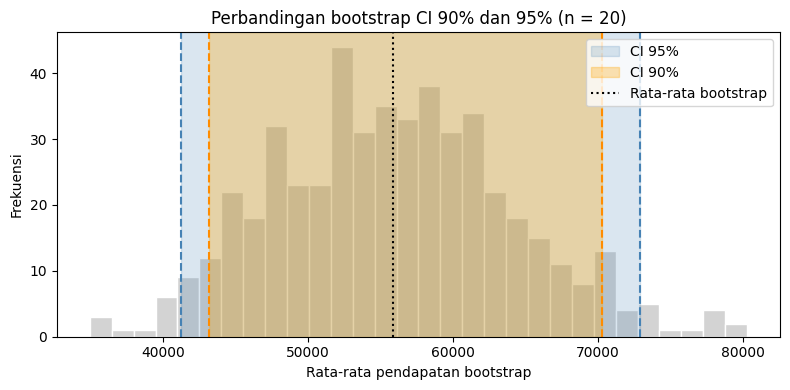

In [11]:
import matplotlib.pyplot as plt

ci90_lower, ci90_upper = bootstrap_means_ci.quantile([0.05, 0.95])
ci95_lower, ci95_upper = bootstrap_means_ci.quantile([0.025, 0.975])

width90 = ci90_upper - ci90_lower
width95 = ci95_upper - ci95_lower

print(f"CI 90%: [{ci90_lower:,.2f}, {ci90_upper:,.2f}]")
print(f"Lebar CI 90%: {width90:,.2f}")
print(f"CI 95%: [{ci95_lower:,.2f}, {ci95_upper:,.2f}]")
print(f"Lebar CI 95%: {width95:,.2f}")

ax = bootstrap_means_ci.plot.hist(
    bins=30, figsize=(8, 4), color="lightgray", edgecolor="white"
)
ax.axvspan(
    ci95_lower, ci95_upper,
    color="steelblue", alpha=0.2, label="CI 95%"
)
ax.axvspan(
    ci90_lower, ci90_upper,
    color="orange", alpha=0.3, label="CI 90%"
)

for boundary in (ci95_lower, ci95_upper):
    ax.axvline(boundary, color="steelblue", linestyle="--")

for boundary in (ci90_lower, ci90_upper):
    ax.axvline(boundary, color="darkorange", linestyle="--")

ax.axvline(
    bootstrap_means_ci.mean(),
    color="black", linestyle=":", label="Rata-rata bootstrap"
)
ax.set_xlabel("Rata-rata pendapatan bootstrap")
ax.set_ylabel("Frekuensi")
ax.set_title("Perbandingan bootstrap CI 90% dan 95% (n = 20)")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretasi Perbandingan Interval

Area oranye menunjukkan CI 90%, sedangkan rentang biru menunjukkan CI 95%. Rentang CI 90% berada di dalam rentang CI 95%.

CI 95% menggunakan persentil yang lebih jauh dari pusat distribusi. Karena itu, batas bawahnya lebih rendah dan batas atasnya lebih tinggi, sehingga interval lebih lebar.

CI 90% memberikan rentang yang lebih sempit dengan target cakupan lebih rendah. CI 95% memberikan rentang lebih lebar dengan target cakupan lebih tinggi.

Perubahan tingkat kepercayaan tidak mengubah sampel awal maupun kumpulan rata-rata bootstrap. Yang berubah adalah persentil yang digunakan untuk menentukan batas interval.

## 15. Normal Distribution (Distribusi Normal)

Distribusi normal, atau distribusi Gaussian, merupakan distribusi kontinu berbentuk lonceng dan simetris terhadap rata-rata.

Dua parameter utamanya adalah:

- $\mu$: rata-rata yang menentukan pusat kurva.
- $\sigma$: simpangan baku yang menentukan lebar penyebaran.

Semakin besar simpangan baku, semakin lebar kurvanya. Pada distribusi normal, mean, median, dan mode berada pada titik yang sama.

### Aturan 68–95–99,7

Untuk variabel yang berdistribusi normal:

| Rentang dari rata-rata | Probabilitas sekitar |
|---|---|
| Dalam ±1 simpangan baku | 68% |
| Dalam ±2 simpangan baku | 95% |
| Dalam ±3 simpangan baku | 99,7% |

Probabilitas suatu rentang ditunjukkan oleh luas di bawah kurva pada rentang tersebut. Luas di bawah seluruh kurva adalah 1 atau 100%.

### Normal Standar

Distribusi normal standar memiliki rata-rata 0 dan simpangan baku 1. Pada distribusi ini, rentang satu simpangan baku dari rata-rata adalah −1 hingga 1.

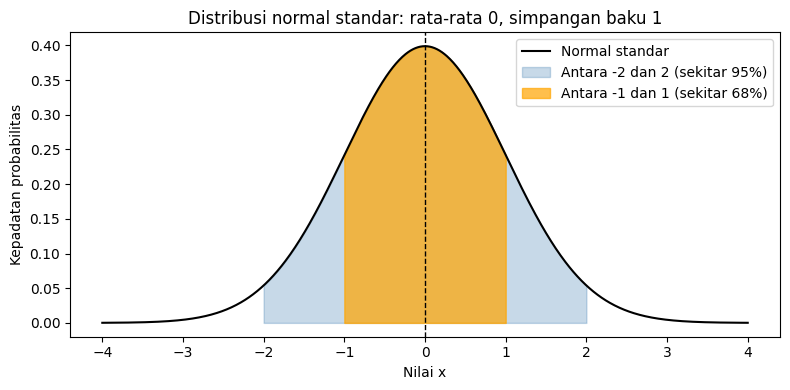

Probabilitas antara -1 dan 1: 68.27%
Probabilitas antara -2 dan 2: 95.45%
Probabilitas antara -3 dan 3: 99.73%


In [12]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 801)
density = stats.norm.pdf(x, loc=0, scale=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, density, color="black", label="Normal standar")

ax.fill_between(
    x, 0, density,
    where=(x >= -2) & (x <= 2),
    color="steelblue", alpha=0.3,
    label="Antara -2 dan 2 (sekitar 95%)",
)
ax.fill_between(
    x, 0, density,
    where=(x >= -1) & (x <= 1),
    color="orange", alpha=0.7,
    label="Antara -1 dan 1 (sekitar 68%)",
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Nilai x")
ax.set_ylabel("Kepadatan probabilitas")
ax.set_title("Distribusi normal standar: rata-rata 0, simpangan baku 1")
ax.legend()

plt.tight_layout()
plt.show()

for k in (1, 2, 3):
    probability = stats.norm.cdf(k) - stats.norm.cdf(-k)
    print(f"Probabilitas antara -{k} dan {k}: {probability:.2%}")

### Interpretasi Kurva Normal

Kurva ini merupakan model normal teoritis dengan pusat 0 dan simpangan baku 1. Bentuknya simetris: sisi kiri dan kanan memiliki pola yang sama.

Area oranye antara −1 dan 1 memiliki probabilitas sekitar 68,27%. Seluruh rentang −2 hingga 2 memiliki probabilitas sekitar 95,45%.

Sumbu vertikal menunjukkan kepadatan probabilitas. Probabilitas untuk suatu rentang diperoleh dari luas di bawah kurva.

Fungsi CDF memberikan probabilitas sampai suatu batas nilai. Karena itu, selisih CDF(k) dan CDF(−k) memberikan probabilitas nilai berada antara −k dan k.

Aturan ini berlaku untuk distribusi normal. Bentuk distribusi data yang digunakan dalam analisis perlu diperiksa terlebih dahulu.

### 15.1. Standardisasi dan Z-Score

Standardisasi dilakukan dengan mengurangi setiap nilai dengan rata-rata, kemudian membaginya dengan simpangan baku.

Ketika rata-rata dan simpangan baku dihitung dari data yang tersedia, rumusnya adalah:

$$
z_i = \frac{x_i - \bar{x}}{s}
$$

Keterangan:

- $x_i$: nilai pengamatan.
- $\bar{x}$: rata-rata data.
- $s$: simpangan baku data.

Z-score menunjukkan posisi suatu pengamatan relatif terhadap rata-rata:

| Z-score | Arti |
|---|---|
| 0 | Tepat pada rata-rata |
| +1 | Satu simpangan baku di atas rata-rata |
| −2 | Dua simpangan baku di bawah rata-rata |

Sebagai ilustrasi, jika nilai seseorang 80, rata-rata 70, dan simpangan baku 10, z-score-nya adalah 1.

Setelah standardisasi, rata-rata data menjadi sekitar 0 dan simpangan bakunya menjadi 1, menggunakan cara perhitungan simpangan baku yang sama.

Standardisasi mempertahankan bentuk distribusi asal sambil mengubah pusat dan skalanya. Jika data asal miring, hasil standardisasinya tetap miring.

In [13]:
import pandas as pd

income_mean = loans_income.mean()
income_sd = loans_income.std(ddof=1)
income_z_scores = (loans_income - income_mean) / income_sd

z_score_comparison = pd.DataFrame({
    "Pendapatan": loans_income,
    "Z-score": income_z_scores,
})

print(f"Rata-rata pendapatan: {income_mean:,.2f}")
print(f"Simpangan baku pendapatan: {income_sd:,.2f}")
print("Lima pengamatan pertama:")
print(z_score_comparison.head())

print(f"Rata-rata z-score: {income_z_scores.mean():.4f}")
print(f"Simpangan baku z-score: {income_z_scores.std(ddof=1):.4f}")

Rata-rata pendapatan: 68,760.52
Simpangan baku pendapatan: 32,872.04
Lima pengamatan pertama:
   Pendapatan   Z-score
0       67000 -0.053557
1       52000 -0.509872
2      100000  0.950336
3       78762  0.304255
4       37041 -0.964939
Rata-rata z-score: 0.0000
Simpangan baku z-score: 1.0000


### Interpretasi Z-Score Pendapatan

Tabel menunjukkan lima pendapatan pertama beserta z-score masing-masing.

Z-score positif menunjukkan pendapatan di atas rata-rata dataset. Z-score negatif menunjukkan pendapatan di bawah rata-rata. Besarnya z-score menyatakan jarak dari rata-rata dalam satuan simpangan baku.

Rata-rata hasil standardisasi mendekati 0, sedangkan simpangan bakunya menjadi 1. Perhitungan ini menggunakan `ddof=1` secara konsisten untuk data asal dan hasil standardisasi.

Nilai hasil standardisasi tidak memiliki satuan pendapatan. Hal ini memudahkan perbandingan posisi relatif pengamatan pada variabel yang memiliki skala berbeda.

### 15.2. QQ-Plot dan Normal Probability Plot

QQ-plot membandingkan kuantil data dengan kuantil distribusi pembanding untuk menilai kesesuaian bentuk distribusinya.

Dalam contoh buku, fungsi `scipy.stats.probplot()` digunakan untuk membuat normal probability plot dengan distribusi normal sebagai pembanding.

Cara membaca grafik:

- Sumbu horizontal menunjukkan kuantil normal teoritis.
- Sumbu vertikal menunjukkan nilai sampel yang diurutkan.
- Pola titik yang mendekati garis lurus menunjukkan kesesuaian dengan bentuk distribusi normal.
- Penyimpangan berpola, misalnya lengkungan atau penyimpangan besar pada ekor, dapat menunjukkan perbedaan dari distribusi normal.

Pada contoh ini, 100 nilai dibangkitkan dari distribusi normal standar dengan rata-rata populasi 0 dan simpangan baku populasi 1. Karena itu, garis diagonal $y=x$ digunakan sebagai acuan.

Penilaian dilakukan dengan memperhatikan pola keseluruhan titik, termasuk bagian tengah dan ekornya.

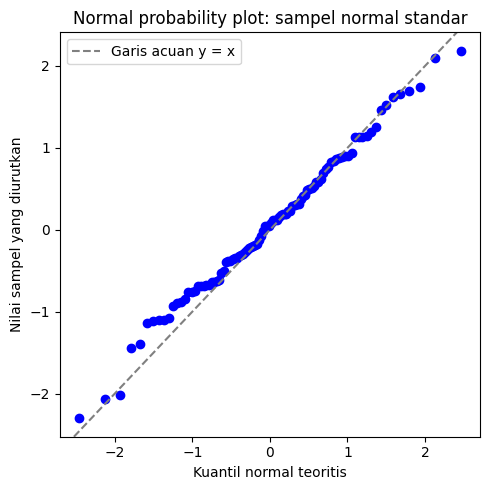

In [14]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(seed=1)
norm_sample = stats.norm.rvs(size=100)

fig, ax = plt.subplots(figsize=(5, 5))

stats.probplot(
    norm_sample, dist="norm", plot=ax, fit=False
)

ax.axline(
    (0, 0), (1, 1),
    color="gray", linestyle="--",
    label="Garis acuan y = x"
)

ax.set_xlabel("Kuantil normal teoritis")
ax.set_ylabel("Nilai sampel yang diurutkan")
ax.set_title("Normal probability plot: sampel normal standar")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretasi Grafik

Titik-titik cenderung mengikuti garis diagonal karena data dibangkitkan dari distribusi normal standar.

Titik sampel dapat sedikit menyimpang dari garis, terutama di bagian ekor. Penyimpangan ini wajar karena sampel hanya berisi 100 pengamatan acak.

Garis diagonal merupakan acuan untuk distribusi normal standar pada contoh ini. Untuk data normal dengan rata-rata atau simpangan baku berbeda, garis pembanding dapat memiliki posisi dan kemiringan berbeda.

Grafik ini membantu menilai kecocokan distribusi secara visual melalui pola keseluruhan titik.

## 16. Long-Tailed Distributions

Ekor distribusi adalah bagian ujung distribusi tempat nilai-nilai ekstrem muncul dengan frekuensi relatif rendah.

Dalam pembahasan buku, distribusi berekor panjang memiliki lebih banyak nilai ekstrem dibandingkan yang diperkirakan oleh model normal dengan skala yang sebanding.

Ekor panjang dan skewness menggambarkan karakteristik yang berbeda:

| Konsep | Makna |
|---|---|
| Ekor panjang | Nilai ekstrem relatif lebih sering muncul |
| Skewness | Distribusi tidak simetris; salah satu ekornya lebih panjang |

Distribusi berekor panjang dapat berbentuk simetris maupun tidak simetris.

Jika data memiliki ekor panjang, asumsi normal dapat meremehkan kemungkinan munculnya kejadian ekstrem. Karena itu, bentuk distribusi perlu diperiksa sebelum memilih model.

Buku menggunakan data saham Netflix, dengan simbol NFLX, sebagai contoh untuk mempelajari pola ekor melalui grafik perbandingan kuantil.

In [15]:
import pandas as pd

SP500_DATA_CSV = (
    "https://raw.githubusercontent.com/gedeck/"
    "practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz"
)

sp500_px = pd.read_csv(
    SP500_DATA_CSV, compression="gzip", index_col=0
)

nflx_changes = sp500_px["NFLX"]

print("Ukuran dataset:", sp500_px.shape)
print("Lima nilai awal NFLX:")
print(nflx_changes.head())

print("Lima nilai positif NFLX:")
print(nflx_changes[nflx_changes > 0].head())

Ukuran dataset: (5647, 517)
Lima nilai awal NFLX:
1993-01-29    0.0
1993-02-01    0.0
1993-02-02    0.0
1993-02-03    0.0
1993-02-04    0.0
Name: NFLX, dtype: float64
Lima nilai positif NFLX:
2002-05-23    0.040000
2002-06-03    0.048571
2002-06-05    0.036429
2002-06-06    0.032143
2002-06-10    0.021429
Name: NFLX, dtype: float64


### Persiapan Data NFLX

Dataset dibaca dari repository pendamping penulis. Kolom pertama digunakan sebagai indeks tanggal.

Setelah tanggal dijadikan indeks, dataset memiliki 5.647 baris dan 517 kolom data instrumen. Kolom `NFLX` dipilih dan disimpan dalam variabel `nflx_changes`.

Kolom ini memuat nilai perubahan harian yang dapat bernilai positif, negatif, atau nol.

Fungsi `.head()` menampilkan lima pengamatan pertama. Pemilihan nilai positif pada bagian berikutnya digunakan sebagai pemeriksaan awal isi kolom.

Data ini akan digunakan pada langkah berikutnya untuk mereproduksi contoh grafik distribusi berekor panjang.

### 16.1. Grafik Distribusi Berekor Panjang pada NFLX

Contoh ini mengikuti transformasi dalam buku: memilih nilai NFLX yang positif, mengambil logaritma natural dengan `np.log()`, kemudian menghitung selisih antara nilai log yang berurutan dengan `np.diff()`.

Hasil transformasi ditampilkan melalui **normal probability plot**. Grafik ini membandingkan nilai data yang telah diurutkan dengan kuantil teoritis distribusi normal. Penyimpangan pada kedua ujung grafik membantu kita melihat perbedaan bentuk ekor data terhadap distribusi normal.

**Catatan tentang dataset:** file pendamping berisi perubahan harian. Karena itu, hasil perhitungan ini merupakan selisih log dari perubahan positif yang dipilih. Perhitungan log-return harga harian memerlukan deret harga penutupan.

Jumlah nilai positif: 1613
Jumlah nilai setelah transformasi: 1612


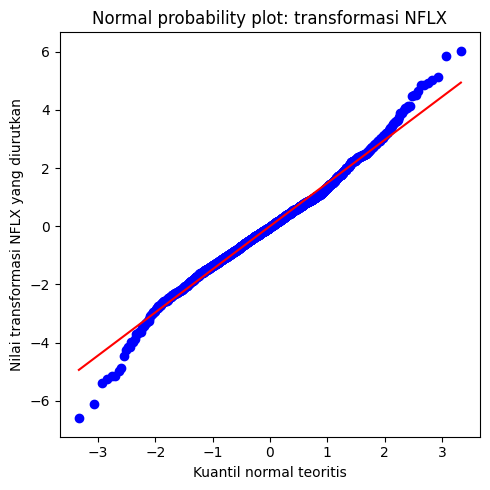

In [16]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Memilih nilai positif dan mengikuti transformasi dalam buku
nflx_positive = nflx_changes[nflx_changes > 0]
nflx_transformed = np.diff(np.log(nflx_positive))

print("Jumlah nilai positif:", len(nflx_positive))
print("Jumlah nilai setelah transformasi:", len(nflx_transformed))

# Membandingkan data dengan kuantil distribusi normal
fig, ax = plt.subplots(figsize=(5, 5))

stats.probplot(
    nflx_transformed,
    dist="norm",
    plot=ax,
    fit=True
)

ax.set_xlabel("Kuantil normal teoritis")
ax.set_ylabel("Nilai transformasi NFLX yang diurutkan")
ax.set_title("Normal probability plot: transformasi NFLX")

plt.tight_layout()
plt.show()

### Interpretasi Grafik

Sumbu horizontal menunjukkan kuantil teoritis distribusi normal, sedangkan sumbu vertikal menunjukkan nilai transformasi NFLX yang diurutkan.

Perhatikan kedua ujung grafik. Pola titik ekstrem di sebelah kiri yang berada di bawah garis pembanding, serta titik ekstrem di sebelah kanan yang berada di atas garis, menunjukkan ekor yang lebih panjang dibandingkan pola normal.

Bagian tengah data dapat cukup dekat dengan garis meskipun kedua ekornya menyimpang. Karena itu, kecocokan pada bagian tengah saja belum cukup untuk menyatakan bahwa seluruh distribusi mengikuti distribusi normal.

Interpretasi ini berlaku untuk deret hasil transformasi yang digunakan dalam contoh.

### 17. Student’s t-Distribution

Distribusi t berbentuk simetris seperti distribusi normal, tetapi memiliki ekor yang lebih tebal. Bentuknya ditentukan oleh **degrees of freedom** atau derajat kebebasan (`df`). Semakin besar `df`, semakin dekat bentuknya dengan distribusi normal standar.

Distribusi ini digunakan dalam inferensi tentang rata-rata ketika simpangan baku populasi tidak diketahui dan diperkirakan menggunakan simpangan baku sampel.

Untuk sampel acak independen dari populasi normal, statistik berikut mengikuti distribusi t dengan derajat kebebasan $n-1$:

$$
T = \frac{\bar{x}-\mu}{s/\sqrt{n}}
$$

Keterangan:

- $\bar{x}$: rata-rata sampel.
- $\mu$: rata-rata populasi.
- $s$: simpangan baku sampel.
- $n$: jumlah observasi.
- $s/\sqrt{n}$: estimasi standard error rata-rata.

Sebagai contoh, sampel berukuran 20 memiliki derajat kebebasan 19 untuk statistik rata-rata satu sampel.

Ekor yang lebih tebal mencerminkan tambahan ketidakpastian karena simpangan baku populasi diestimasi dari sampel.

**Kode berikut merupakan ilustrasi tambahan** untuk membandingkan kurva distribusi t dan normal standar.

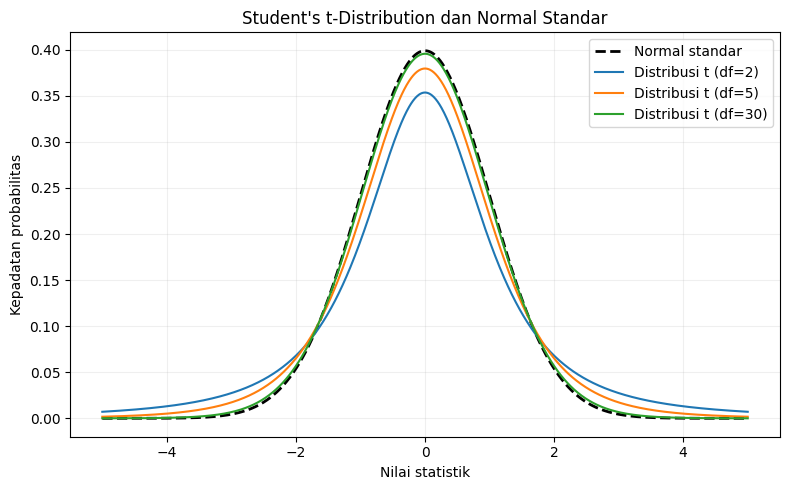

In [17]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(8, 5))

# Kurva normal standar sebagai pembanding
plt.plot(
    x,
    stats.norm.pdf(x),
    color="black",
    linestyle="--",
    linewidth=2,
    label="Normal standar"
)

# Kurva distribusi t dengan beberapa derajat kebebasan
for df in [2, 5, 30]:
    plt.plot(
        x,
        stats.t.pdf(x, df=df),
        label=f"Distribusi t (df={df})"
    )

plt.xlabel("Nilai statistik")
plt.ylabel("Kepadatan probabilitas")
plt.title("Student's t-Distribution dan Normal Standar")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretasi Grafik

Garis hitam putus-putus menunjukkan distribusi normal standar. Tiga kurva lainnya menunjukkan distribusi t dengan derajat kebebasan yang berbeda.

Di antara kurva t yang ditampilkan, kurva dengan `df=2` memiliki ekor paling tebal dan puncak lebih rendah. Ketika derajat kebebasan meningkat menjadi 5 dan 30, bentuk kurva semakin mendekati normal standar.

Grafik ini memperlihatkan bahwa distribusi t memberikan lebih banyak peluang pada nilai yang jauh dari pusat dibandingkan distribusi normal standar, terutama ketika derajat kebebasannya kecil.

Sumbu vertikal menunjukkan kepadatan. Probabilitas suatu rentang nilai diperoleh dari luas di bawah kurva pada rentang tersebut.

### 17.1. Confidence Interval Rata-rata dengan Distribusi t

Confidence interval untuk rata-rata dapat dihitung menggunakan rata-rata sampel, estimasi standard error, dan nilai kritis distribusi t.

Untuk interval dua sisi dengan tingkat kepercayaan 90%, rumusnya adalah:

$$
CI_{90\%} = \bar{x} \pm t_{0.95,\;n-1}\frac{s}{\sqrt{n}}
$$

Nilai $\alpha=0.10$ dibagi menjadi 5% pada masing-masing ekor. Karena itu, batas kritis positif menggunakan kuantil 0.95.

**Margin of error** dihitung sebagai:

$$
ME = t_{0.95,\;n-1}\frac{s}{\sqrt{n}}
$$

Batas bawah adalah $\bar{x}-ME$, sedangkan batas atas adalah $\bar{x}+ME$.

Contoh berikut menerapkan rumus buku menggunakan kembali sampel 20 pendapatan dari bagian bootstrap. Kode Python ini merupakan ilustrasi tambahan penerapan rumus.

In [18]:
import numpy as np
from scipy import stats

# Menggunakan kembali sampel sebelumnya
n_t = len(sample20_ci)
df_t = n_t - 1

mean_t = sample20_ci.mean()
sd_t = sample20_ci.std(ddof=1)
se_t = sd_t / np.sqrt(n_t)

# CI dua sisi 90%: masing-masing ekor memiliki luas 5%
t_critical_90 = stats.t.ppf(0.95, df=df_t)
margin_t_90 = t_critical_90 * se_t

ci_t_90_lower = mean_t - margin_t_90
ci_t_90_upper = mean_t + margin_t_90

print("Jumlah sampel:", n_t)
print("Degrees of freedom:", df_t)
print(f"Rata-rata sampel: {mean_t:,.2f}")
print(f"Standard error: {se_t:,.2f}")
print(f"Nilai kritis t: {t_critical_90:.4f}")
print(f"Margin of error: {margin_t_90:,.2f}")
print(
    f"CI t 90% rata-rata: "
    f"[{ci_t_90_lower:,.2f}, {ci_t_90_upper:,.2f}]"
)

Jumlah sampel: 20
Degrees of freedom: 19
Rata-rata sampel: 55,734.10
Standard error: 8,384.82
Nilai kritis t: 1.7291
Margin of error: 14,498.47
CI t 90% rata-rata: [41,235.63, 70,232.57]


### Interpretasi Hasil

Interval yang diperoleh berpusat pada rata-rata sampel. Margin of error menunjukkan jarak dari rata-rata sampel menuju masing-masing batas interval. Semakin besar standard error, semakin lebar interval pada tingkat kepercayaan dan derajat kebebasan yang sama.

Tingkat kepercayaan 90% berkaitan dengan prosedur pengambilan sampel berulang. Jika asumsi metode terpenuhi, sekitar 90% interval yang dibentuk melalui pengulangan tersebut akan mencakup rata-rata populasi.

Interval t memiliki cakupan tepat untuk pengamatan independen dari populasi normal. Data pendapatan dalam contoh ini berbentuk miring dan sampelnya hanya 20, sehingga cakupan aktual 90% tidak otomatis terjamin. Contoh ini digunakan untuk mempelajari penerapan rumus.

Hasilnya dapat berbeda dari interval bootstrap sebelumnya karena kedua metode menggunakan cara yang berbeda untuk menentukan batas interval.

### 18. Binomial Distribution

Distribusi binomial menggambarkan **jumlah keberhasilan dalam sejumlah percobaan**. Contohnya, menghitung jumlah pembelian dari lima pengunjung.

Model binomial memiliki syarat:

- Jumlah percobaan tetap, yaitu $n$.
- Setiap percobaan memiliki dua hasil: keberhasilan atau kegagalan.
- Peluang keberhasilan $p$ sama pada setiap percobaan.
- Percobaan saling independen.

Satu percobaan dengan dua hasil disebut **percobaan Bernoulli**. Jumlah keberhasilan dari $n$ percobaan tersebut mengikuti distribusi binomial.

Jika $X$ adalah jumlah keberhasilan, peluang tepat $k$ keberhasilan adalah:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

Simbol $\binom{n}{k}$ menunjukkan banyaknya cara memilih posisi $k$ keberhasilan dari $n$ percobaan.

Rata-rata dan varians distribusi binomial adalah:

$$
E(X)=np
$$

$$
Var(X)=np(1-p)
$$

Distribusi binomial dapat didekati dengan distribusi normal ketika $np$ dan $n(1-p)$ cukup besar.

Contoh buku menggunakan $n=5$ dan $p=0.1$ untuk menghitung peluang tepat dua keberhasilan serta peluang dua atau kurang keberhasilan.

P(X = 2): 0.0729 (7.29%)
P(X <= 2): 0.9914 (99.14%)
Rata-rata teoretis: 0.50
Varians teoretis: 0.45


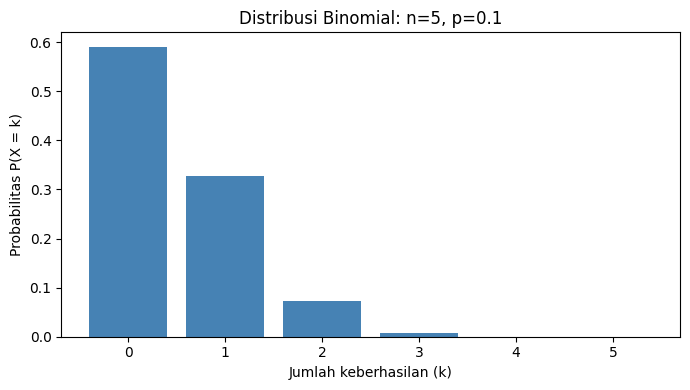

In [19]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

n_binom = 5
p_binom = 0.1

# Reproduksi perhitungan dalam buku
prob_exact_2 = stats.binom.pmf(2, n=n_binom, p=p_binom)
prob_upto_2 = stats.binom.cdf(2, n=n_binom, p=p_binom)

print(f"P(X = 2): {prob_exact_2:.4f} ({prob_exact_2:.2%})")
print(f"P(X <= 2): {prob_upto_2:.4f} ({prob_upto_2:.2%})")

# Ilustrasi tambahan: rata-rata dan varians teoretis
print(f"Rata-rata teoretis: {n_binom * p_binom:.2f}")
print(f"Varians teoretis: {n_binom * p_binom * (1 - p_binom):.2f}")

# Ilustrasi tambahan: grafik probabilitas
k_binom = np.arange(n_binom + 1)
probabilities_binom = stats.binom.pmf(
    k_binom, n=n_binom, p=p_binom
)

plt.figure(figsize=(7, 4))
plt.bar(k_binom, probabilities_binom, color="steelblue")
plt.xticks(k_binom)
plt.xlabel("Jumlah keberhasilan (k)")
plt.ylabel("Probabilitas P(X = k)")
plt.title("Distribusi Binomial: n=5, p=0.1")

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Peluang memperoleh **tepat dua keberhasilan** dalam lima percobaan adalah 7.29%, ketika peluang keberhasilan pada setiap percobaan sebesar 10%.

Peluang memperoleh **dua atau kurang keberhasilan** adalah sekitar 99.14%. Nilai ini menjumlahkan peluang memperoleh nol, satu, dan dua keberhasilan.

Pada grafik, probabilitas terbesar berada pada nol keberhasilan. Hal ini sesuai dengan peluang keberhasilan per percobaan yang kecil.

Rata-rata teoretis sebesar 0.50 berarti bahwa jika kelompok lima percobaan diulang berkali-kali, rata-rata jumlah keberhasilan per kelompok akan mendekati 0.50. Jumlah keberhasilan dalam setiap kelompok tetap berupa bilangan bulat.

### 19. Chi-Square Distribution

Distribusi chi-square, ditulis $\chi^2$, merupakan distribusi kontinu dengan nilai nonnegatif. Bentuknya miring ke kanan, terutama ketika derajat kebebasannya kecil.

Distribusi ini digunakan sebagai acuan untuk menilai perbedaan antara **frekuensi yang diamati** dan **frekuensi yang diharapkan berdasarkan hipotesis nol**.

Statistik chi-square Pearson dihitung dengan:

$$
\chi^2 = \sum_i \frac{(O_i-E_i)^2}{E_i}
$$

Keterangan:

- $O_i$: jumlah pengamatan pada kategori atau sel ke-$i$.
- $E_i$: jumlah yang diharapkan berdasarkan model hipotesis nol.
- Penjumlahan dilakukan untuk seluruh kategori atau sel.

Nilai statistik yang kecil menunjukkan frekuensi pengamatan dekat dengan frekuensi harapan. Nilai yang besar menunjukkan penyimpangan yang lebih besar.

Penggunaannya mencakup **uji goodness of fit**, untuk menilai kesesuaian frekuensi dengan model tertentu, serta **uji independensi**, untuk menilai hubungan antara dua variabel kategoris.

Bentuk distribusi ditentukan oleh **derajat kebebasan (`df`)**. Untuk goodness of fit dengan $k$ kategori dan peluang kategori yang sudah ditetapkan, derajat kebebasannya adalah $k-1$.

Pada pengujian frekuensi kategori, distribusi chi-square menjadi pendekatan yang memerlukan pengamatan independen dan frekuensi harapan yang memadai.

**Kode berikut merupakan ilustrasi tambahan** untuk membandingkan bentuk kurva pada beberapa derajat kebebasan.

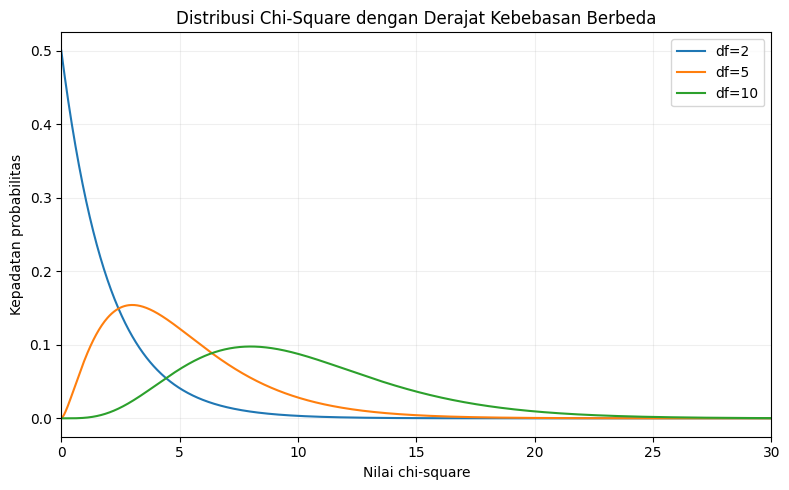

In [20]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

chi2_values = np.linspace(0, 30, 1000)

plt.figure(figsize=(8, 5))

for df_chi2 in [2, 5, 10]:
    plt.plot(
        chi2_values,
        stats.chi2.pdf(chi2_values, df=df_chi2),
        label=f"df={df_chi2}"
    )

plt.xlabel("Nilai chi-square")
plt.ylabel("Kepadatan probabilitas")
plt.title("Distribusi Chi-Square dengan Derajat Kebebasan Berbeda")
plt.xlim(0, 30)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretasi Grafik

Ketiga kurva berada pada nilai chi-square yang nonnegatif.

Kurva dengan `df=2` memiliki kepadatan tertinggi dekat nol dan menurun ke kanan. Pada `df=5` dan `df=10`, puncak kurva berada lebih jauh dari nol.

Ketika derajat kebebasan meningkat, distribusi bergeser ke kanan dan kemiringan relatifnya berkurang. Karena itu, nilai statistik harus dinilai menggunakan distribusi acuan dengan derajat kebebasan yang sesuai.

Sumbu vertikal menunjukkan kepadatan probabilitas. Probabilitas suatu rentang nilai ditentukan oleh luas di bawah kurva pada rentang tersebut.

Penerapan uji chi-square pada data akan dibahas lebih lanjut dalam Chapter 3.

### 20. F-Distribution

Distribusi F merupakan distribusi kontinu dengan nilai nonnegatif dan bentuk yang miring ke kanan. Bentuknya ditentukan oleh **dua derajat kebebasan**: untuk pembilang dan penyebut.

Distribusi ini digunakan dalam **ANOVA (Analysis of Variance)** untuk menilai perbedaan rata-rata beberapa kelompok.

Statistik F pada ANOVA dihitung sebagai:

$$
F = \frac{MS_{\text{antar kelompok}}}{MS_{\text{dalam kelompok}}}
$$

**Mean square (MS)** adalah jumlah kuadrat penyimpangan yang dibagi dengan derajat kebebasannya.

Pembilang mengukur variasi antar rata-rata kelompok, sedangkan penyebut mengukur variasi pengamatan di dalam kelompok. Nilai F yang besar menunjukkan variasi antar kelompok yang besar relatif terhadap variasi di dalam kelompok.

Hipotesis nol ANOVA menyatakan bahwa rata-rata populasi seluruh kelompok sama.

Pada ANOVA satu arah klasik, derajat kebebasannya adalah:

$$
df_1=k-1,\qquad df_2=N-k
$$

Di sini, $k$ adalah jumlah kelompok dan $N$ adalah jumlah seluruh pengamatan.

Penggunaan distribusi F sebagai acuan pada ANOVA klasik mengasumsikan pengamatan independen, populasi normal pada setiap kelompok, dan varians populasi yang sama antar kelompok.

Distribusi F juga digunakan dalam pengujian keseluruhan model regresi linear.

**Kode berikut merupakan ilustrasi tambahan** untuk membandingkan kurva distribusi F pada beberapa pasangan derajat kebebasan.

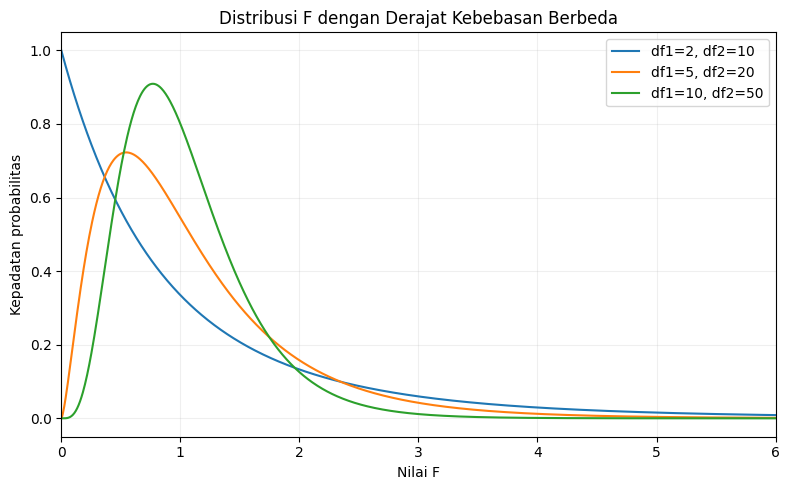

In [21]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

f_values = np.linspace(0.001, 6, 1000)
df_pairs_f = [(2, 10), (5, 20), (10, 50)]

plt.figure(figsize=(8, 5))

for df1_f, df2_f in df_pairs_f:
    plt.plot(
        f_values,
        stats.f.pdf(f_values, dfn=df1_f, dfd=df2_f),
        label=f"df1={df1_f}, df2={df2_f}"
    )

plt.xlabel("Nilai F")
plt.ylabel("Kepadatan probabilitas")
plt.title("Distribusi F dengan Derajat Kebebasan Berbeda")
plt.xlim(0, 6)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretasi Grafik

Ketiga kurva menunjukkan bahwa bentuk distribusi F berubah sesuai pasangan derajat kebebasannya.

Di antara kurva yang ditampilkan, pasangan `df1=10` dan `df2=50` lebih terkonsentrasi di sekitar nilai 1. Pasangan `df1=2` dan `df2=10` lebih menyebar dan memiliki ekor kanan yang lebih panjang.

Dalam ANOVA, nilai F yang besar perlu dibandingkan dengan distribusi acuan yang memiliki derajat kebebasan sesuai. Penilaian ini membantu menentukan apakah perbedaan rata-rata kelompok melebihi variasi yang wajar menurut hipotesis nol.

Sumbu vertikal menunjukkan kepadatan. Probabilitas suatu rentang nilai diperoleh dari luas di bawah kurva pada rentang tersebut.

### 21. Poisson Distribution

Distribusi Poisson memodelkan **jumlah kejadian dalam interval waktu atau wilayah tertentu**. Contohnya adalah jumlah panggilan layanan pelanggan per menit atau jumlah cacat pada satu meter persegi kain.

Parameter $\lambda$ menunjukkan rata-rata jumlah kejadian pada interval yang ditentukan. Jika rata-rata kedatangan adalah dua panggilan per menit, maka untuk interval satu menit digunakan $\lambda=2$.

Peluang memperoleh tepat $k$ kejadian adalah:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},
\qquad k=0,1,2,\ldots
$$

Rata-rata dan varians teoretisnya sama:

$$
E(X)=\lambda,\qquad Var(X)=\lambda
$$

Model proses Poisson mengasumsikan laju kejadian tetap dan jumlah kejadian pada interval yang tidak tumpang tindih saling independen. Jika laju berubah menurut waktu, analisis dapat dilakukan pada rentang waktu yang relatif seragam.

Contoh berikut mereproduksi simulasi buku: menghasilkan 100 jumlah panggilan dengan $\lambda=2$. Setiap nilai mewakili jumlah panggilan dalam satu menit, sehingga seluruh data menggambarkan 100 menit.

Jumlah menit simulasi: 100
Rata-rata teoritis: 2.00
Rata-rata simulasi: 1.96
Varians simulasi: 2.28


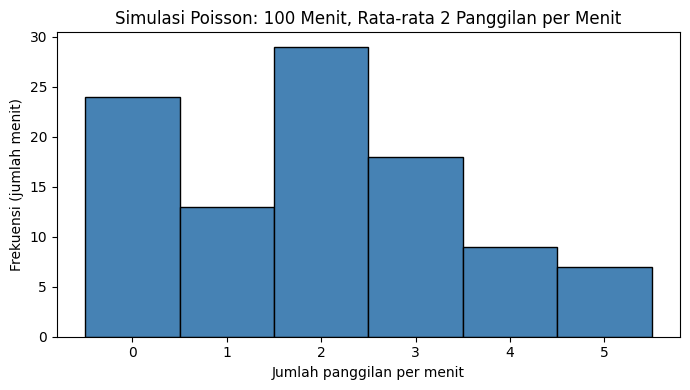

In [22]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

lambda_poisson = 2

# Reproduksi simulasi buku, dengan seed agar dapat diulang
poisson_sample = stats.poisson.rvs(
    mu=lambda_poisson,
    size=100,
    random_state=1
)

print("Jumlah menit simulasi:", len(poisson_sample))
print(f"Rata-rata teoritis: {lambda_poisson:.2f}")
print(f"Rata-rata simulasi: {poisson_sample.mean():.2f}")
print(f"Varians simulasi: {poisson_sample.var(ddof=1):.2f}")

# Satu bin untuk setiap jumlah panggilan bulat
bin_edges_poisson = np.arange(
    -0.5, poisson_sample.max() + 1.5, 1
)

ax = pd.Series(poisson_sample).plot.hist(
    bins=bin_edges_poisson,
    figsize=(7, 4),
    color="steelblue",
    edgecolor="black"
)

ax.set_xticks(np.arange(poisson_sample.max() + 1))
ax.set_xlabel("Jumlah panggilan per menit")
ax.set_ylabel("Frekuensi (jumlah menit)")
ax.set_title("Simulasi Poisson: 100 Menit, Rata-rata 2 Panggilan per Menit")

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Sumbu horizontal menunjukkan jumlah panggilan dalam satu menit. Sumbu vertikal menunjukkan banyaknya menit yang memiliki jumlah panggilan tersebut.

Sebagai contoh, batang pada angka 0 menunjukkan jumlah menit tanpa panggilan. Batang pada angka 2 menunjukkan jumlah menit dengan tepat dua panggilan.

Jumlah panggilan dapat berbeda antar menit meskipun laju rata-ratanya tetap. Dalam model dengan $\lambda=2$, jumlah panggilan yang jauh lebih besar dari dua cenderung lebih jarang.

Rata-rata dan varians teoretis sama-sama sebesar 2. Nilai rata-rata dan varians dari 100 hasil simulasi dapat berbeda dari angka tersebut karena variasi acak.

### 22. Exponential Distribution

Distribusi eksponensial memodelkan **waktu tunggu antar kejadian** dalam proses Poisson dengan laju tetap. Contohnya adalah waktu antara dua panggilan layanan pelanggan atau antara dua kendaraan yang datang.

Waktu tunggu merupakan nilai kontinu yang nonnegatif. Distribusi ini juga digunakan untuk memodelkan waktu sampai kegagalan ketika laju kegagalannya tetap.

Jika laju kejadian adalah $\lambda$, fungsi kepadatannya adalah:

$$
f(t)=\lambda e^{-\lambda t},\qquad t\geq0
$$

Rata-rata dan variansnya adalah:

$$
E(T)=\frac{1}{\lambda},
\qquad Var(T)=\frac{1}{\lambda^2}
$$

Contoh buku menggunakan laju 0.2 panggilan per menit. Rata-rata waktu tunggunya adalah:

$$
E(T)=\frac{1}{0.2}=5\text{ menit}
$$

Dalam SciPy, parameter yang digunakan adalah `scale`, dengan hubungan:

$$
scale=\frac{1}{\lambda}
$$

**Catatan reproduksi:** buku cetak menuliskan `stats.expon.rvs(0.2, size=100)`. Dalam SciPy, argumen posisi pertama tersebut adalah `loc`. Reproduksi ini mengikuti notebook pendamping penulis yang menggunakan `scale=5`, agar sesuai dengan laju 0.2 panggilan per menit.

Jumlah interval waktu tunggu: 100
Laju kedatangan: 0.20 panggilan/menit
Rata-rata waktu tunggu teoretis: 5.00 menit
Rata-rata waktu tunggu simulasi: 4.74 menit


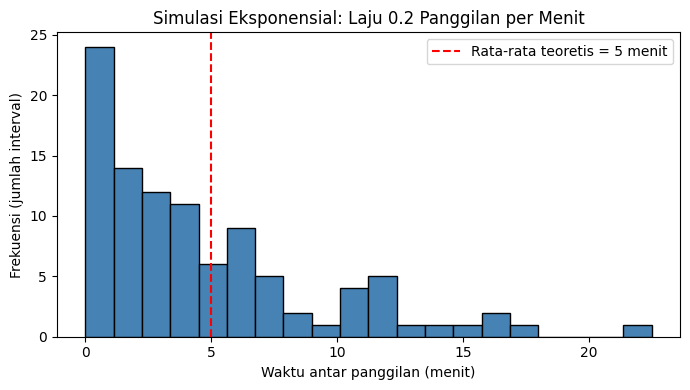

In [23]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

lambda_exp = 0.2
scale_exp = 1 / lambda_exp

# Mengikuti parameter pada notebook pendamping penulis
exponential_sample = stats.expon.rvs(
    loc=0,
    scale=scale_exp,
    size=100,
    random_state=1
)

print("Jumlah interval waktu tunggu:", len(exponential_sample))
print(f"Laju kedatangan: {lambda_exp:.2f} panggilan/menit")
print(f"Rata-rata waktu tunggu teoretis: {scale_exp:.2f} menit")
print(f"Rata-rata waktu tunggu simulasi: {exponential_sample.mean():.2f} menit")

ax = pd.Series(exponential_sample).plot.hist(
    bins=20,
    figsize=(7, 4),
    color="steelblue",
    edgecolor="black"
)

ax.axvline(
    scale_exp,
    color="red",
    linestyle="--",
    label="Rata-rata teoretis = 5 menit"
)

ax.set_xlabel("Waktu antar panggilan (menit)")
ax.set_ylabel("Frekuensi (jumlah interval)")
ax.set_title("Simulasi Eksponensial: Laju 0.2 Panggilan per Menit")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretasi Hasil

Sumbu horizontal menunjukkan waktu antar panggilan dalam menit. Sumbu vertikal menunjukkan jumlah interval waktu tunggu pada setiap rentang histogram.

Distribusi eksponensial memiliki banyak waktu tunggu pendek dan sebagian waktu tunggu panjang, sehingga bentuknya miring ke kanan.

Garis merah menunjukkan rata-rata teoretis sebesar lima menit. Waktu tunggu setiap kejadian dapat lebih pendek atau lebih panjang dari nilai tersebut.

Data simulasi berisi 100 waktu tunggu yang panjangnya berbeda-beda. Rata-rata sampelnya dapat berbeda dari lima menit karena variasi acak.

### 23. Estimating the Failure Rate

Laju kegagalan menunjukkan rata-rata jumlah kegagalan per satuan waktu. Pada model dengan laju tetap, estimasinya dapat dihitung sebagai:

$$
\hat{\lambda}=\frac{N}{T}
$$

Di sini, $N$ adalah jumlah kegagalan yang diamati dan $T$ adalah total waktu operasi yang diamati.

Kejadian yang langka membuat laju kegagalan sulit diperkirakan secara presisi. Sebagai contoh, buku membahas pengamatan tanpa kegagalan selama 20 jam.

Walaupun estimasi titiknya adalah $0/20=0$, laju positif yang kecil masih dapat menghasilkan nol kegagalan dalam waktu pengamatan tersebut.

Dalam model Poisson, rata-rata jumlah kegagalan selama waktu $T$ adalah $\lambda T$. Peluang mengamati nol kegagalan adalah:

$$
P(N=0)=e^{-\lambda T}
$$

Perhitungan peluang atau simulasi dapat membantu membandingkan beberapa laju yang mungkin ketika data kegagalan terbatas.

**Kode berikut merupakan ilustrasi tambahan** untuk membandingkan tiga laju hipotetis pada pengamatan selama 20 jam.

In [24]:
from scipy import stats

exposure_hours = 20
observed_failures = 0

estimated_failure_rate = observed_failures / exposure_hours

print("Jumlah kegagalan diamati:", observed_failures)
print("Total waktu pengamatan:", exposure_hours, "jam")
print(f"Estimasi laju: {estimated_failure_rate:.4f} kegagalan/jam")

for hypothetical_rate in [0.01, 0.1, 1.0]:
    expected_failures = hypothetical_rate * exposure_hours

    probability_zero = stats.poisson.pmf(
        0, mu=expected_failures
    )

    print(
        f"Laju {hypothetical_rate:.2f}/jam -> "
        f"rata-rata dalam 20 jam = {expected_failures:.2f}, "
        f"P(nol kegagalan) = {probability_zero:.10f}"
    )

Jumlah kegagalan diamati: 0
Total waktu pengamatan: 20 jam
Estimasi laju: 0.0000 kegagalan/jam
Laju 0.01/jam -> rata-rata dalam 20 jam = 0.20, P(nol kegagalan) = 0.8187307531
Laju 0.10/jam -> rata-rata dalam 20 jam = 2.00, P(nol kegagalan) = 0.1353352832
Laju 1.00/jam -> rata-rata dalam 20 jam = 20.00, P(nol kegagalan) = 0.0000000021


### Interpretasi Hasil

Jika laju kegagalan sebesar 0.01 per jam, peluang mengamati nol kegagalan selama 20 jam sekitar 81.87%.

Jika lajunya sebesar satu kegagalan per jam, peluang memperoleh pengamatan tanpa kegagalan selama 20 jam sangat kecil. Karena itu, laju tersebut kurang sejalan dengan pengamatan dalam contoh.

Angka yang dihitung merupakan peluang mengamati nol kegagalan **jika laju tertentu diasumsikan berlaku**.

Hasil ini memperlihatkan bahwa pengamatan tanpa kegagalan masih dapat terjadi pada laju positif. Ketika data terbatas, estimasi laju perlu disertai penilaian ketidakpastian.

### 24. Weibull Distribution

Distribusi Weibull digunakan untuk memodelkan waktu sampai suatu komponen mengalami kegagalan. Distribusi ini dapat menggambarkan laju kegagalan yang berubah seiring usia komponen.

Laju kegagalan atau **hazard** adalah laju kegagalan pada usia tertentu, dengan syarat komponen masih berfungsi sampai usia tersebut.

Distribusi Weibull memiliki dua parameter utama:

- **Shape (β)** menentukan perubahan laju kegagalan.
  - β < 1: laju kegagalan menurun seiring usia.
  - β = 1: laju kegagalan konstan; Weibull menjadi distribusi eksponensial.
  - β > 1: laju kegagalan meningkat seiring usia.
- **Scale (η)** menentukan skala waktu dan disebut umur karakteristik. Sekitar 63,2% komponen dalam model mengalami kegagalan sebelum mencapai waktu η.

Untuk waktu t ≥ 0, probabilitas kegagalan sebelum atau pada waktu t adalah:

$$
P(T \leq t) = 1 - e^{-(t/\eta)^\beta}
$$

Parameter scale bukan selalu rata-rata umur. Rata-rata umur bergantung pada shape dan scale.

Contoh buku menggunakan shape = 1,5 dan scale = 5.000 untuk menyimulasikan 100 waktu sampai kegagalan. Dalam notebook ini, satuan waktunya dinyatakan dalam jam sebagai ilustrasi.

Karena shape > 1, model menggambarkan komponen dengan laju kegagalan yang meningkat seiring usia. Dalam penerapan nyata, parameter shape dan scale diestimasi dari data umur komponen.

Jumlah umur simulasi: 100
Parameter bentuk: 1.5
Parameter skala: 5,000.00 jam
Rata-rata umur teoretis: 4,513.73 jam
Rata-rata umur simulasi: 4,347.15 jam


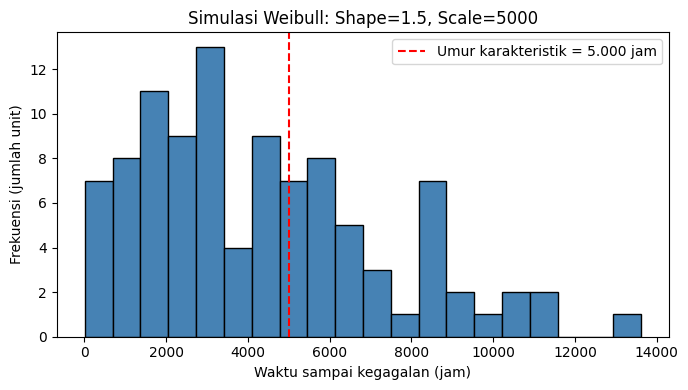

In [25]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

shape_weibull = 1.5
scale_weibull = 5000

weibull_sample = stats.weibull_min.rvs(
    c=shape_weibull,
    scale=scale_weibull,
    size=100,
    random_state=1
)

mean_theoretical_weibull = stats.weibull_min.mean(
    c=shape_weibull,
    scale=scale_weibull
)

print("Jumlah umur simulasi:", len(weibull_sample))
print("Parameter bentuk:", shape_weibull)
print(f"Parameter skala: {scale_weibull:,.2f} jam")
print(f"Rata-rata umur teoretis: {mean_theoretical_weibull:,.2f} jam")
print(f"Rata-rata umur simulasi: {weibull_sample.mean():,.2f} jam")

ax = pd.Series(weibull_sample).plot.hist(
    bins=20,
    figsize=(7, 4),
    color="steelblue",
    edgecolor="black"
)

ax.axvline(
    scale_weibull,
    color="red",
    linestyle="--",
    label="Umur karakteristik = 5.000 jam"
)

ax.set_xlabel("Waktu sampai kegagalan (jam)")
ax.set_ylabel("Frekuensi (jumlah unit)")
ax.set_title("Simulasi Weibull: Shape=1.5, Scale=5000")
ax.legend()

plt.tight_layout()
plt.show()

#### Interpretasi Hasil

Histogram menunjukkan sebaran waktu sampai kegagalan untuk 100 komponen simulasi. Sumbu horizontal menunjukkan umur dalam jam, sedangkan sumbu vertikal menunjukkan jumlah komponen pada setiap rentang umur.

Garis merah menunjukkan umur karakteristik sebesar 5.000 jam. Dalam model Weibull ini, sekitar 63,2% komponen mengalami kegagalan sebelum mencapai umur tersebut. Persentase dalam sampel simulasi dapat berbeda.

Rata-rata umur teoretis sekitar 4.513,73 jam. Nilai ini berbeda dari scale karena rata-rata bergantung pada kedua parameter Weibull.

Shape sebesar 1,5 berarti laju kegagalan meningkat seiring usia, dengan syarat komponen masih berfungsi sampai usia tersebut. Histogram menggambarkan sebaran umur; histogram ini bukan grafik laju kegagalan.

Data yang digunakan merupakan hasil simulasi, sehingga interpretasinya menjelaskan perilaku model dan belum membuktikan pola kegagalan suatu komponen nyata.

### 25. Ringkasan Chapter 2 — Data and Sampling Distributions

Chapter 2 membahas cara mengambil sampel, memahami variasi hasil estimasi, dan menggunakan distribusi probabilitas untuk menggambarkan data serta ketidakpastiannya.

Konsep utama yang dipelajari adalah:

1. **Population dan sample**  
   Populasi adalah keseluruhan objek yang ingin dipelajari, sedangkan sampel merupakan bagian dari populasi. Pemilihan sampel secara acak membantu mengurangi bias pemilihan.

2. **Kualitas sampel dan bias**  
   Sampel besar tidak otomatis mewakili populasi. Selection bias, kesalahan pengukuran, dan pemilihan hasil berdasarkan data dapat menghasilkan kesimpulan yang keliru.

3. **Regression to the mean**  
   Hasil yang sangat ekstrem dapat menjadi lebih dekat ke rata-rata pada pengukuran berikutnya karena variasi acak. Perubahan tersebut belum tentu merupakan akibat suatu perlakuan.

4. **Sampling distribution dan Central Limit Theorem**  
   Sampling distribution menggambarkan variasi suatu statistik dari pengambilan sampel berulang. Untuk observasi independen dengan distribusi yang sama dan varians terbatas, distribusi rata-rata sampel mendekati normal ketika ukuran sampel cukup besar.

5. **Standard error**  
   Standard error mengukur variasi estimator antar-sampel. Untuk rata-rata dari observasi independen dengan distribusi yang sama, estimasinya adalah simpangan baku sampel dibagi akar ukuran sampel. Ukuran sampel yang lebih besar biasanya menghasilkan estimasi lebih presisi.

6. **Bootstrap**  
   Bootstrap mengambil sampel berulang dengan pengembalian dari data yang diamati. Metode ini dapat digunakan untuk mengestimasi standard error, bias, dan confidence interval. Bootstrap tetap bergantung pada kualitas sampel dan asumsi pengambilan datanya.

7. **Confidence interval**  
   Confidence interval menyatakan ketidakpastian estimasi parameter populasi. Tingkat kepercayaan berkaitan dengan cakupan prosedur dalam pengambilan sampel berulang. Pada contoh notebook, interval 95% lebih lebar daripada interval 90%.

8. **Normal distribution, z-score, dan long-tailed distributions**  
   Distribusi normal berbentuk simetris. Z-score mengubah skala data tanpa mengubah bentuk distribusinya. Probability plot membantu memeriksa kesesuaian terhadap distribusi normal dan penyimpangan pada bagian ekor.

9. **Student’s t, chi-square, dan F distribution**  
   Distribusi ini menjadi dasar berbagai metode inferensi statistik. Student’s t digunakan dalam inferensi rata-rata ketika simpangan baku populasi tidak diketahui, chi-square digunakan pada analisis frekuensi kategori, dan F digunakan dalam perbandingan variasi seperti ANOVA. Setiap metode memiliki asumsi yang perlu diperiksa.

10. **Binomial, Poisson, exponential, dan Weibull distribution**  
    Binomial memodelkan jumlah keberhasilan dalam sejumlah percobaan tetap. Poisson memodelkan jumlah kejadian dalam suatu interval. Exponential memodelkan waktu tunggu dengan laju kejadian konstan, sedangkan Weibull dapat menggambarkan laju kegagalan yang berubah seiring usia.

Pemahaman konsep-konsep tersebut membantu menilai kualitas data dan ketidakpastian estimasi sebelum membangun atau mengevaluasi model machine learning.